# gRPC Concurrency Recon

Compare latency and throughput across different  different gRPC semaphore configuration (`GRPC_CONCURRENCY_LIMIT`) to find the optimal setting.

- Signing latency (`signing_started_at` to `signed_at`): Represents the time taken for signature generation, excluding the time spent queued while waiting for semaphore lock acquisition.
- End-to-end latency (`created_at` to `confirmed_at`): Represents the time taken for complete transaction processing, from the moment a request arrives at the system until the transaction is confirmed in a block.
- TPS (overall confirmations / total time span): Represents system throughput.

The optimal setting minimises e2e latency and maximises TPS without overloading signers.

---
### 1. Init

In [ ]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pathlib import Path
from faultlab.analysis import load_csv, execution_summary, aggregate_summaries

sns.set_theme(style="whitegrid")

PROJECT_ROOT_DIR = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT_DIR.joinpath("src")))

RESULTS_DIR = PROJECT_ROOT_DIR.joinpath("tests/results").joinpath("GRPC_CONCURRENCY_LIMIT")

print(f"GRPC Results dir  : {RESULTS_DIR}")

Project root : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab
Results dir  : /Users/kr1sel/Documents/Code/|_MSC_Proj_|/faultlab/tests/results


---
### 2. Per-concurrency analysis

In [ ]:
import re
from collections import defaultdict

all_summaries = defaultdict(list)

# Regex to strip the _YYYYMMDD_HHMMSS timestamp suffix
timestamp_re = re.compile(r"_\d{8}_\d{6}$")

if RESULTS_DIR.exists():
    for run_dir in RESULTS_DIR.iterdir():
        if run_dir.is_dir() and run_dir.name.isdigit():

            for csv_path in run_dir.glob("*.csv"):
                # Strip the timestamp to get the prefix
                prefix = timestamp_re.sub("", csv_path.stem)

                try:
                    # Extract the config value from the prefix
                    limit = int(prefix.rsplit("_", 1)[-1])
                except ValueError:
                    continue

                df = load_csv(csv_path)
                if not df.empty:
                    all_summaries[limit].append(execution_summary(df))

agg_rows = []
for limit, summaries in sorted(all_summaries.items()):
    row = aggregate_summaries(summaries)
    if row:
        row["semaphore_limit"] = limit
        agg_rows.append(row)

res_df = pd.DataFrame(agg_rows).set_index("semaphore_limit").sort_index()

pd.set_option("display.max_columns", None)
display(res_df)

,n_runs,total_txs,confirmed_txs,swept_txs,success_rate_mean,success_rate_std,overall_tps_mean,overall_tps_std,e2e_median_s_mean,e2e_median_s_std,pure_sign_median_s_mean,pure_sign_median_s_std,signing_queue_median_s_mean,signing_queue_median_s_std,submission_median_s_mean,submission_median_s_std,confirmation_median_s_mean,confirmation_median_s_std
semaphore_limit,,,,,,,,,,,,,,,,,,
10,10,10000,10000,0,100.0,0.0,42.276,4.676,20.827,3.785,0.110,0.022,8.761,1.274,7.046,1.291,3.904,0.688
30,10,10000,10000,0,100.0,0.0,40.577,5.617,22.002,4.978,0.297,0.065,7.727,1.281,8.826,2.161,4.175,0.928
50,10,10000,10000,0,100.0,0.0,40.390,3.953,22.005,3.052,0.465,0.071,7.508,0.702,9.206,1.758,4.399,0.937
100,10,10000,10000,0,100.0,0.0,39.774,4.305,22.792,3.426,0.903,0.168,7.276,0.855,9.651,1.867,4.856,0.700
200,10,10000,10000,0,100.0,0.0,38.799,4.052,23.445,3.234,1.819,0.305,7.627,0.974,9.898,1.642,5.153,0.669
1000,10,10000,10000,0,100.0,0.0,36.387,3.558,25.328,2.816,7.581,0.927,9.753,0.931,9.185,1.300,6.184,0.835


---
### 3. Identify optimal configuration

In [3]:
best_tps = int(res_df["overall_tps_mean"].idxmax())
best_e2e = int(res_df["e2e_median_s_mean"].idxmin())
best_sign = int(res_df["pure_sign_median_s_mean"].idxmin())
best_queue = int(res_df["signing_queue_median_s_mean"].idxmin())

print("=" * 60)
print(f"  Best TPS (mean)                  ->  GRPC_LIMIT = {best_tps}")
print(f"  Lowest e2e median (mean)         ->  GRPC_LIMIT = {best_e2e}")
print(f"  Lowest pure-sign median (mean)   ->  GRPC_LIMIT = {best_sign}")
print(f"  Lowest full sign median (mean)   ->  GRPC_LIMIT = {best_sign}")
print("=" * 60)


  Best TPS (mean)                  ->  GRPC_LIMIT = 10
  Lowest e2e median (mean)         ->  GRPC_LIMIT = 10
  Lowest pure-sign median (mean)   ->  GRPC_LIMIT = 10
  Lowest full sign median (mean)   ->  GRPC_LIMIT = 10


---
### 4. Plot results

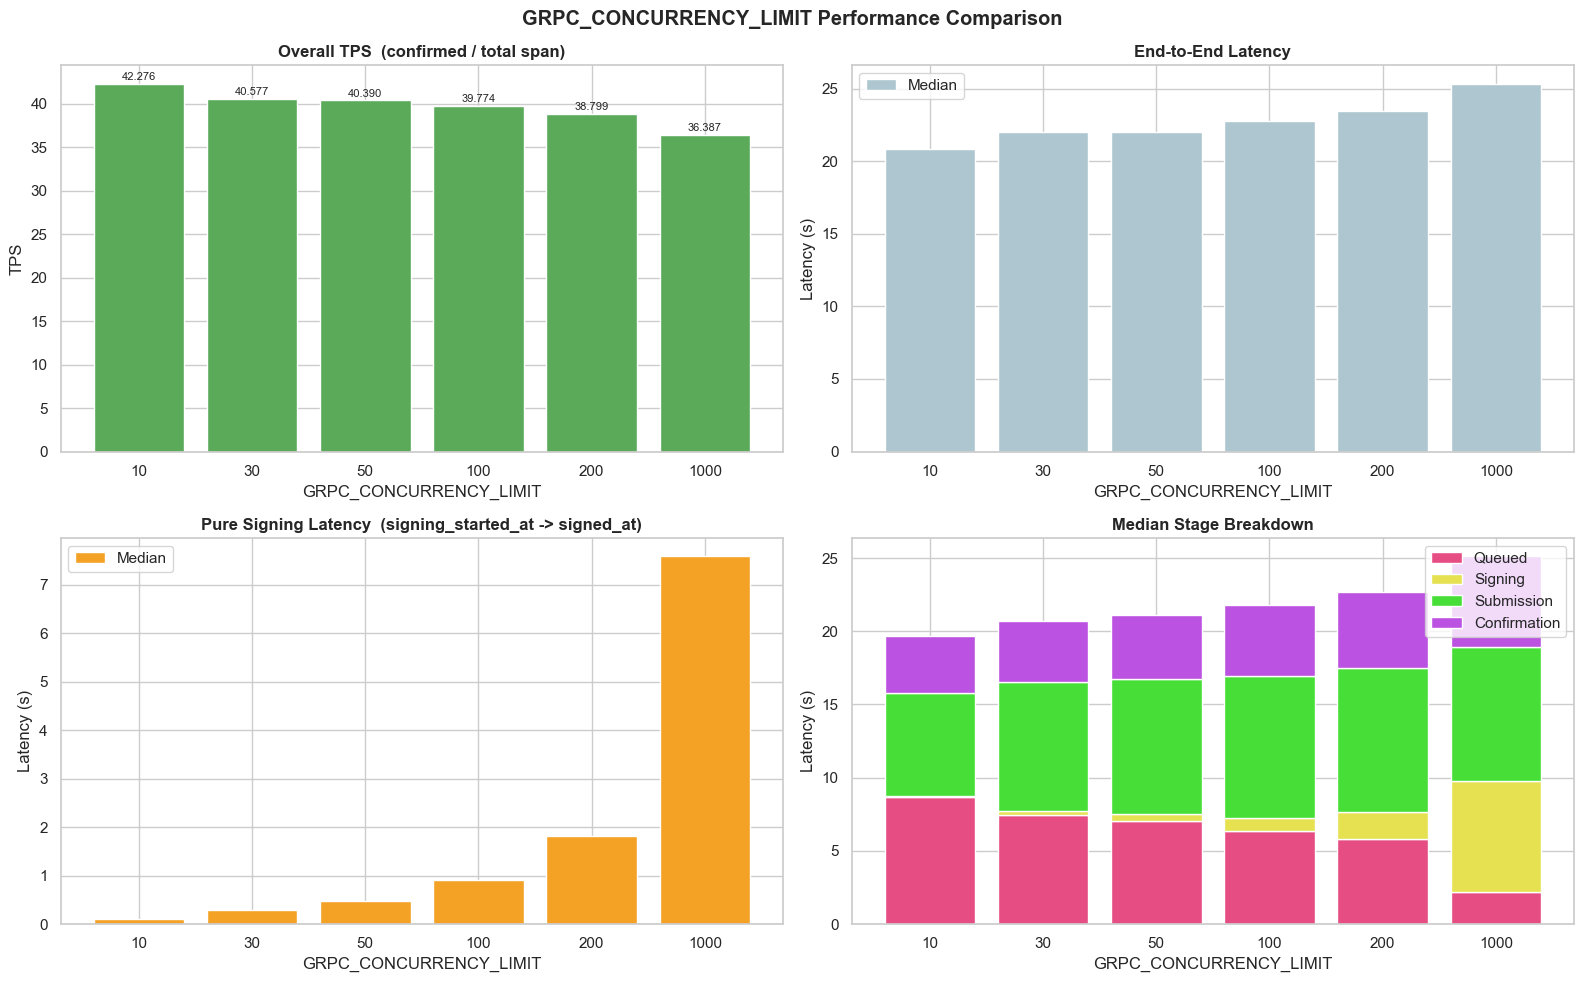

In [4]:
x_labels = [str(v) for v in res_df.index.tolist()]

_, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1 — Overall TPS
axes[0, 0].bar(x_labels, res_df["overall_tps_mean"], color="#5aaa5a")
axes[0, 0].set_title("Overall TPS  (confirmed / total span)", fontweight="bold")
axes[0, 0].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[0, 0].set_ylabel("TPS")
for i, v in enumerate(res_df["overall_tps_mean"]):
    axes[0, 0].text(x=i, y=v + max(res_df["overall_tps_mean"]) * 0.01, s=f"{v:.3f}", ha="center", fontsize=8)

# 2 — E2E latency: median bar
axes[0, 1].bar(x_labels, res_df["e2e_median_s_mean"], color="#aec6cf", label="Median")
axes[0, 1].set_title("End-to-End Latency", fontweight="bold")
axes[0, 1].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[0, 1].set_ylabel("Latency (s)")
axes[0, 1].legend()

# 3 — Pure signing latency: median bar
axes[1, 0].bar(x_labels, res_df["pure_sign_median_s_mean"], color="#f4a226", label="Median")
axes[1, 0].set_title("Pure Signing Latency  (signing_started_at -> signed_at)", fontweight="bold")
axes[1, 0].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[1, 0].set_ylabel("Latency (s)")
axes[1, 0].legend()

# 4 — Stacked stage breakdown
res_df["queue_wait_s"] = (res_df["signing_queue_median_s_mean"] - res_df["pure_sign_median_s_mean"]).clip(lower=0)
stages        = ["queue_wait_s", "pure_sign_median_s_mean", "submission_median_s_mean", "confirmation_median_s_mean"]
stage_colors  = ["#e64e83", "#e6e150", "#48de38", "#bc52e2"]
stage_labels  = ["Queued", "Signing", "Submission", "Confirmation"]

bottom = pd.Series([0.0] * len(res_df), index=res_df.index)
for col, color, label in zip(stages, stage_colors, stage_labels):
    axes[1, 1].bar(x_labels, res_df[col], bottom=bottom.values, color=color, label=label)
    bottom += res_df[col]
axes[1, 1].set_title("Median Stage Breakdown", fontweight="bold")
axes[1, 1].set_xlabel("GRPC_CONCURRENCY_LIMIT")
axes[1, 1].set_ylabel("Latency (s)")
axes[1, 1].legend()

plt.suptitle("GRPC_CONCURRENCY_LIMIT Performance Comparison", fontweight="bold")
plt.tight_layout()
plt.show()
